## Solving an advection-diffusion equation with finite differences using Neural Physics

The Neural Physics code solves discretised systems with untrained neural networks. It is used here to solve a 2D advection diffusion equation,
$$
\frac{\partial c}{\partial t} + u\frac{\partial c}{\partial x} +  v\frac{\partial c}{\partial y} = k \nabla^2 c \,,
$$
where $c$ represents a scalar field (concentration, for example), $u$ and $v$ are the advection velocity componenets and $k$ is the diffusivity.  

More details can be found in Chen B, Heaney CE, Pain CC. [Neural physics: Using AI libraries to develop physics-based solvers for incompressible computational fluid dynamics](https://doi.org/10.1016/j.compfluid.2026.106981). Computers & Fluids 308:106981, 2026.



## Load modules from Python/Pytorch

In [12]:
import os
import numpy as np 
#import pandas as pd
import time 
import math
import random
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F


# Check if GPU is available 
is_gpu = torch.cuda.is_available()
device = torch.device("cuda" if is_gpu else "cpu")
print(is_gpu)

False


## Load modules from Neural Physics

In [13]:
#import Neural_Physics_utils
#import inspect

#functions = [
#    name for name, obj in inspect.getmembers(Neural_Physics_utils, inspect.isfunction)
#]

#print(functions)

from Neural_Physics_utils               import create_tensors_adv_diff_2D, get_weights_adv_diff_2D


## Initialise numerical parameters

In [14]:
dt = 0.05                               # Time step (s)
dx = 1.0 ; dy = 1.0                     # Grid size (m)
k = 1.0                                 # Diffusivity 
u = 1.0                                 # Advection velocity (u component) (m/s)
v = 2.0                                 # Advection velocity (v component) (m/s)
nx = 256 ; ny = 256                     # Grid point
lx = dx * nx ; ly = dy * ny             # Domain size (m)
ntime = 1000                            # Time step
n_out = 100                             # Time steps to plot results 
bias_initializer = torch.tensor([0.0])  # Initial bias as 0 for NNs 

## Initialise the neural network weights with the numerical discretisation

In [15]:
[w1, w2, w3] = get_weights_adv_diff_2D(dx)         # simple centred finite differences
print('w2', w2.shape, w2.dtype)
print(w2)


All the required 2D filters have been created successfully!
w1    => second order derivative  - (1,1,3,3)
w2    => first order derivative x - (1,1,3,3)
w3    => first order derivative y - (1,1,3,3)
w2 torch.Size([1, 1, 3, 3]) torch.float32
tensor([[[[ 0.0000,  0.0000,  0.0000],
          [-0.5000,  0.0000,  0.5000],
          [ 0.0000,  0.0000,  0.0000]]]])


## Establish the Neural Physics solver

In [16]:
class NPsolver(nn.Module):
    """docstring for NPsolver"""
    def __init__(self):
        super(NPsolver, self).__init__()
        # self.arg = arg
        self.diff = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)
        self.xadv = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)
        self.yadv = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)

        self.diff.weight.data = w1
        self.xadv.weight.data = w2
        self.yadv.weight.data = w3

        self.diff.bias.data = bias_initializer
        self.xadv.bias.data = bias_initializer
        self.yadv.bias.data = bias_initializer
        
    def forward(self, values_c, values_cc, predictor_c, dt):  
        """ Solve a finite difference discretisation of the advection diffusion equation using a predictor-corrector method in time"""
        # Apply boundary conditions through padding by using PyTorch's .pad function
        values_cc = F.pad(values_c, (1, 1, 1, 1), mode='constant', value=0)
        # Apply the discretised operators to the concentration fields
        ADx_c = self.xadv(values_cc) ; ADy_c = self.yadv(values_cc) ; AD2_c = self.diff(values_cc) 
        # Calculate the predictor step
        predictor_c = values_c + dt * (k * AD2_c - u * ADx_c - v * ADy_c)  
        # Approximate the solution at the half step c^{n+1/2}
        predictor_c = 0.5 * (predictor_c + values_c)
        # Add padding to c^{n+1/2}
        predictor_cc = F.pad(predictor_c, (1, 1, 1, 1), mode='constant', value=0) 
        # Apply the discretised operators to the concentration fields
        ADx_c = self.xadv(predictor_cc) ; ADy_c = self.yadv(predictor_cc) ; AD2_c = self.diff(predictor_cc)  
        # Calculate the correction step
        values_c = values_c + dt * (k * AD2_c - u * ADx_c - v * ADy_c)    # corrector step
        
        return values_c

## Send the model to the device (CPU or GPU)

In [17]:
NPsolver = NPsolver().to(device)

## Create initial tensors 

In [18]:
values_c, values_cc, predictor_cc, results, times = create_tensors_adv_diff_2D(nx, ny, ntime)

All the required 2D tensors have been created successfully!
values_c     => concentration             - (1,1,ny,nx)
values_cc    => concentration             - (1,1,ny+2,nx+2)
predictor_cc => concentration [predictor] - (1,1,ny+2,nx+2)


## Initialise source

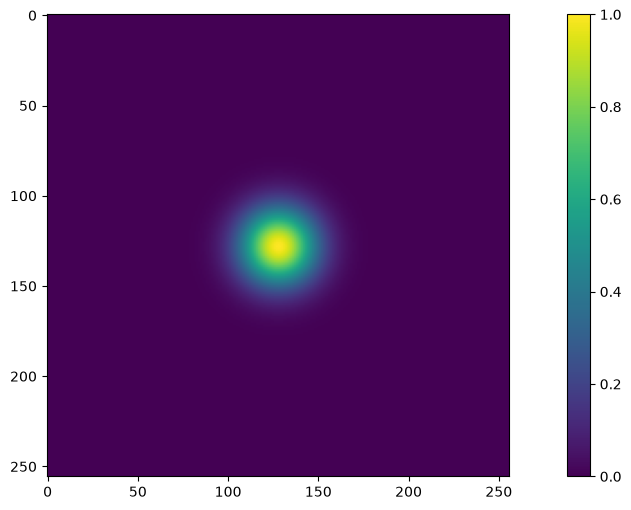

In [19]:
# choose between initial_condition = "gaussian" or initial_condition = "square"
initial_condition = "gaussian"

# Reset the scalar field
values_c.zero_()

# Domain centre
centre_x = nx // 2
centre_y = ny // 2

if initial_condition == "square":

    half_width = 25

    values_c[
        0, 0,
        centre_y - half_width : centre_y + half_width,
        centre_x - half_width : centre_x + half_width
    ] = 1.0

elif initial_condition == "gaussian":

    gaussian_sigma = 15.0

    y = torch.arange(ny, device=device, dtype=torch.float32)
    x = torch.arange(nx, device=device, dtype=torch.float32)
    Y, X = torch.meshgrid(y, x, indexing="ij")

    gaussian = torch.exp(
        -(
            (X - centre_x) ** 2
            + (Y - centre_y) ** 2
        )
        / (2.0 * gaussian_sigma**2)
    )

    values_c[0, 0] = gaussian

else:
    raise ValueError(
        "initial_condition must be either 'square' or 'gaussian'."
    )


plt.figure(figsize=(15, 6))
plt.imshow(values_c[0,0,:,:].cpu())
plt.colorbar()

## Run Neural Physics solver

In [ ]:
start = time.time()
print("============================================================================")
print("Welcome to the Neural Physics that will solve an advection-diffusion problem")
print("============================================================================")
print("Summarising setup before running Neural Physics ............................")
print(f"Device: {device}")
print(f'advection velocity ---------------- {(u,v)} (m/s)')
print(f'Time step ------------------------- {dt} (s)')
print(f'Grid size ------------------------- {dx} (m)')
print("============================================================================")
print("\n Neural Physics is running now...\n")

            
with torch.no_grad():
    for itime in range(1,ntime+1):
        values_c = NPsolver(values_c,values_cc,predictor_cc,dt)
        results[itime,:,:,:,:] = values_c.cpu()
        times[itime] = dt * itime

        if itime % n_out == 0 or itime == ntime:
            print(f"Completed time step {itime:>5d}/{ntime}")
                    
end = time.time()

print(f"\n Simulation completed in {end - start:.2f} s.")
print("\n ============================================================================")


Welcome to the Neural Physics that will solve an advection-diffusion problem
Summarising setup before running Neural Physics ............................
Device: cpu
advection velocity ---------------- (1.0, 2.0) (m/s)
Time step ------------------------- 0.05 (s)
Grid size ------------------------- 1.0 (m)

 Neural Physics is running now...

Completed time step   100/1000
Completed time step   200/1000
Completed time step   300/1000
Completed time step   400/1000
Completed time step   500/1000
Completed time step   600/1000


## Visualise solution

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

im1 = ax[0].imshow(results[1, 0, 0, :, :].cpu(), origin='lower')
fig.colorbar(im1, ax=ax[0])
ax[0].set_title('Initial Condition')

im2 = ax[1].imshow(results[ntime, 0, 0, :, :].cpu(), origin='lower')
fig.colorbar(im2, ax=ax[1])
ax[1].set_title(f'Solution after {ntime} time steps')


plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"


a = results[::20, 0, 0].detach().cpu().numpy()

fig = px.imshow(
    a,
    animation_frame=0, 
    color_continuous_scale="Viridis",
    zmin=a.min(),
    zmax=a.max(), 
    origin='lower'
)

fig.update_coloraxes(colorbar_x=0.75)
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 50


fig.show()

## More details can be found in our recent publications:

- Chen B, Heaney CE, Pain CC. [Neural Physics: Using AI libraries to develop physics-based solvers for incompressible computational fluid dynamics](https://doi.org/10.1016/j.compfluid.2026.106981). Computers & Fluids 308:106981, 2026.

- Phillips TR, Heaney CE, Chen B, Buchan AG, Pain CC. [Solving the discretised neutron diffusion equations using neural networks](https://doi.org/10.1002/nme.7321). International Journal for Numerical Methods in Engineering. 2023 Nov 15;124(21):4659-86. 

- Phillips TR, Heaney CE, Chen B, Buchan AG, Pain CC. [Solving the Discretised Boltzmann Transport Equations using Neural Networks: Applications in Neutron Transport](https://doi.org/10.48550/arXiv.2301.09991). arXiv preprint arXiv:2301.09991. 2023 Jan 24. 

- Chen B, Heaney CE, Gomes JL, Matar OK, Pain CC. [Solving the Discretised Multiphase Flow Equations with Interface Capturing on Structured Grids Using Machine Learning Libraries]( https://doi.org/10.1016/j.cma.2024.116974). Computer Methods in Applied Mechanics and Engineering. 2024 June 1; 426: 0045-7825.

Contact: Prof Christopher C. Pain (c.pain@imperial.ac.uk), Dr Claire E. Heaney (c.heaney@imperial.ac.uk), Dr Boyang Chen (boyang.chen16@imperial.ac.uk). [Applied Modelling and Computation Group](https://www.imperial.ac.uk/earth-science/research/research-groups/amcg/), Department of Earth Science and Engineering, Imperial College London